<a href="https://colab.research.google.com/github/kudinha/4100-Lab-Dialysis/blob/code/Dialysis_day2_EV_2%3A51_ODR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This script solves for questions 1-3 in Lab Day 2 discussions.

Imports/loading data

In [8]:
#!pip install uncertainties -q

In [9]:
import numpy as np
import pandas as pd
from google.colab import files

GPH_TO_LPS = 3.78541 / 3600
STREAMS = ["Tube In", "Tube Out", "Shell In", "Shell Out"]
V_COLS = ["Tube_In_A0_V", "Tube_Out_A1_V", "Shell_In_A2_V", "Shell_Out_A3_V"]

T_C = 25                 # deg C — update to your measured temperature
NU = 0.893e-6            # kinematic viscosity of water at 25 C [m^2/s]
D_AB = 1.99e-9           # KCl in water, infinite dilution, 25 C [m^2/s]

SC = NU / D_AB           # Schmidt number, eqn [5]

Equations 9-11

In [10]:
def logmeanconc(c):
    """Counter-current log-mean concentration difference, eqn [10]."""
    c_ri, c_ro, c_di, c_do = c
    return ((c_ro - c_di) - (c_ri - c_do)) / np.log((c_ro - c_di) / (c_ri - c_do))

def transfer_solute(q_ri, q_ro, c_ri, c_ro):
    """Solute transfer out of feed stream, eqn [11]. Q in L/s, C in mol/L -> mol/s."""
    return q_ri * c_ri - q_ro * c_ro

def k_a_calc(w_r, area, dc_lm):
    """Overall dialysis coefficient, eqn [9]. Converts mol/L -> mol/m^3 so K_A is in m/s."""
    return w_r / (area * dc_lm * 1000)

Data loading

In [11]:
def load_file(path, n_ss=30):
    """One row per run: steady-state voltages (last n_ss points) + flows from Summary."""
    sheets = pd.read_excel(path, sheet_name=None)
    rows = []
    for _, s in sheets["Summary"].iterrows():
        tail = sheets[f"RUN {int(s['Run Number'])}"][V_COLS].tail(n_ss)
        row = {"file": path.split("/")[-1], "solute": s["Solute"], "run": int(s["Run Number"])}
        for st, col in zip(STREAMS, V_COLS):
            row[f"V {st}"] = tail[col].mean()
            row[f"Q {st}"] = s[f"Total {st} Flow (GPH)"] * GPH_TO_LPS
            row[f"dQ {st}"] = s[f"Total {st} Error (GPH)"] * GPH_TO_LPS
        rows.append(row)
    return pd.DataFrame(rows)

Flow rate calibration

In [12]:
from uncertainties import ufloat

# 1. Upload and read the raw sheet
uploaded = files.upload()
filename = list(uploaded.keys())[-1]   # most recent upload
raw = pd.read_excel(filename, header=None)

# 2. Locate each table by its "tube in" label cell
def find_label(raw, text):
    for r in range(raw.shape[0]):
        for c in range(raw.shape[1]):
            v = raw.iat[r, c]
            if isinstance(v, str) and text in v.lower():
                return r, c
    raise ValueError(f"Could not find a cell containing '{text}'")

def extract(raw, tag, n_rows=6, n_cols=5):
    r0, c0 = find_label(raw, tag)
    block = raw.iloc[r0:r0 + n_rows, c0:c0 + n_cols + 1].copy()
    labels = block.iloc[:, 0].astype(str).str.strip()
    data = block.iloc[:, 1:].apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace("GPH", "", regex=False).str.strip(),
            errors="coerce"))
    data.index = labels
    if r0 > 0:
        hdr = raw.iloc[r0 - 1, c0 + 1:c0 + n_cols + 1].astype(str).str.strip()
        data.columns = hdr.values
    return data

# Plain numeric tables (kept for plotting)
small = extract(raw, "small tube in")
big = extract(raw, "big tube in")

# 3. Uncertainties
VOL_ERR = 2            # mL
TIME_ERR = 1           # s
SMALL_FLOW_ERR = 0.05  # GPH
BIG_FLOW_ERR = 0.1     # GPH

# 4. Convert every cell to a ufloat (value ± error)
def to_ufloat_table(table, flow_err):
    out = table.astype(object).copy()
    for row in table.index:
        r = row.lower()
        if "volume" in r:
            e = VOL_ERR
        elif "time" in r:
            e = TIME_ERR
        else:
            e = flow_err
        for col in table.columns:
            out.loc[row, col] = ufloat(table.loc[row, col], e)
    return out

small_u = to_ufloat_table(small, SMALL_FLOW_ERR)
big_u = to_ufloat_table(big, BIG_FLOW_ERR)

print("SMALL (ufloat)\n", small_u, "\n")
print("BIG (ufloat)\n", big_u)

# 5. Flow from volume and time (GPH); errors propagate automatically
ML_PER_S_TO_GPH = 3600 / 3785.41

def volume_flow(table_u):
    V = table_u.loc[[r for r in table_u.index if "volume" in r.lower()][0]]
    t = table_u.loc[[r for r in table_u.index if "time" in r.lower()][0]]
    return V / t * ML_PER_S_TO_GPH   # Series of ufloats

Q_small_u = volume_flow(small_u)
Q_big_u = volume_flow(big_u)

print("\nSmall: flow from volume/time (GPH)\n", Q_small_u)
print("\nBig: flow from volume/time (GPH)\n", Q_big_u)

# 6. Plain float versions so the plotting cell still works unchanged
Q_small  = Q_small_u.apply(lambda q: q.n).astype(float)
dQ_small = Q_small_u.apply(lambda q: q.s).astype(float)
Q_big    = Q_big_u.apply(lambda q: q.n).astype(float)
dQ_big   = Q_big_u.apply(lambda q: q.s).astype(float)

Saving lab2_flow_calibration (1).xlsx to lab2_flow_calibration (1).xlsx
SMALL (ufloat)
                              1 GPH      1.6 GPH      1.1 GPH        2 GPH  \
0                                                                           
small tube in (GPH)    1.00+/-0.05  1.60+/-0.05  1.10+/-0.05  2.00+/-0.05   
small shell out (GPH)  0.90+/-0.05  1.40+/-0.05  1.00+/-0.05  1.90+/-0.05   
small shell in (GPH)   1.00+/-0.05  1.50+/-0.05  1.10+/-0.05  2.00+/-0.05   
small tube out (GPH)   1.00+/-0.05  1.55+/-0.05  1.10+/-0.05  2.00+/-0.05   
volume filled (ml)      40.0+/-2.0   40.0+/-2.0   40.0+/-2.0   40.0+/-2.0   
time (sec)              42.8+/-1.0   26.5+/-1.0   37.6+/-1.0   20.4+/-1.0   

                           0.4 GPH  
0                                   
small tube in (GPH)    0.40+/-0.05  
small shell out (GPH)  0.25+/-0.05  
small shell in (GPH)   0.40+/-0.05  
small tube out (GPH)   0.40+/-0.05  
volume filled (ml)      20.0+/-2.0  
time (sec)              75.4+/-1.0  

small tube in (GPH): slope = 1.0121+/-0.0304, intercept = -0.1386+/-0.0318
small shell out (GPH): slope = 1.0002+/-0.0198, intercept = 0.0025+/-0.0184
small shell in (GPH): slope = 1.0439+/-0.0264, intercept = -0.1562+/-0.0272
small tube out (GPH): slope = 1.0283+/-0.0227, intercept = -0.1478+/-0.0236
big tube in (GPH: slope = 0.9862+/-0.0188, intercept = -0.0861+/-0.0478
big shell out (GPH): slope = 0.9592+/-0.0136, intercept = 0.1049+/-0.0332
big shell in (GPH): slope = 1.0033+/-0.0085, intercept = -0.1097+/-0.0216
big tube out (GPH): slope = 0.9585+/-0.0091, intercept = -0.0568+/-0.0235


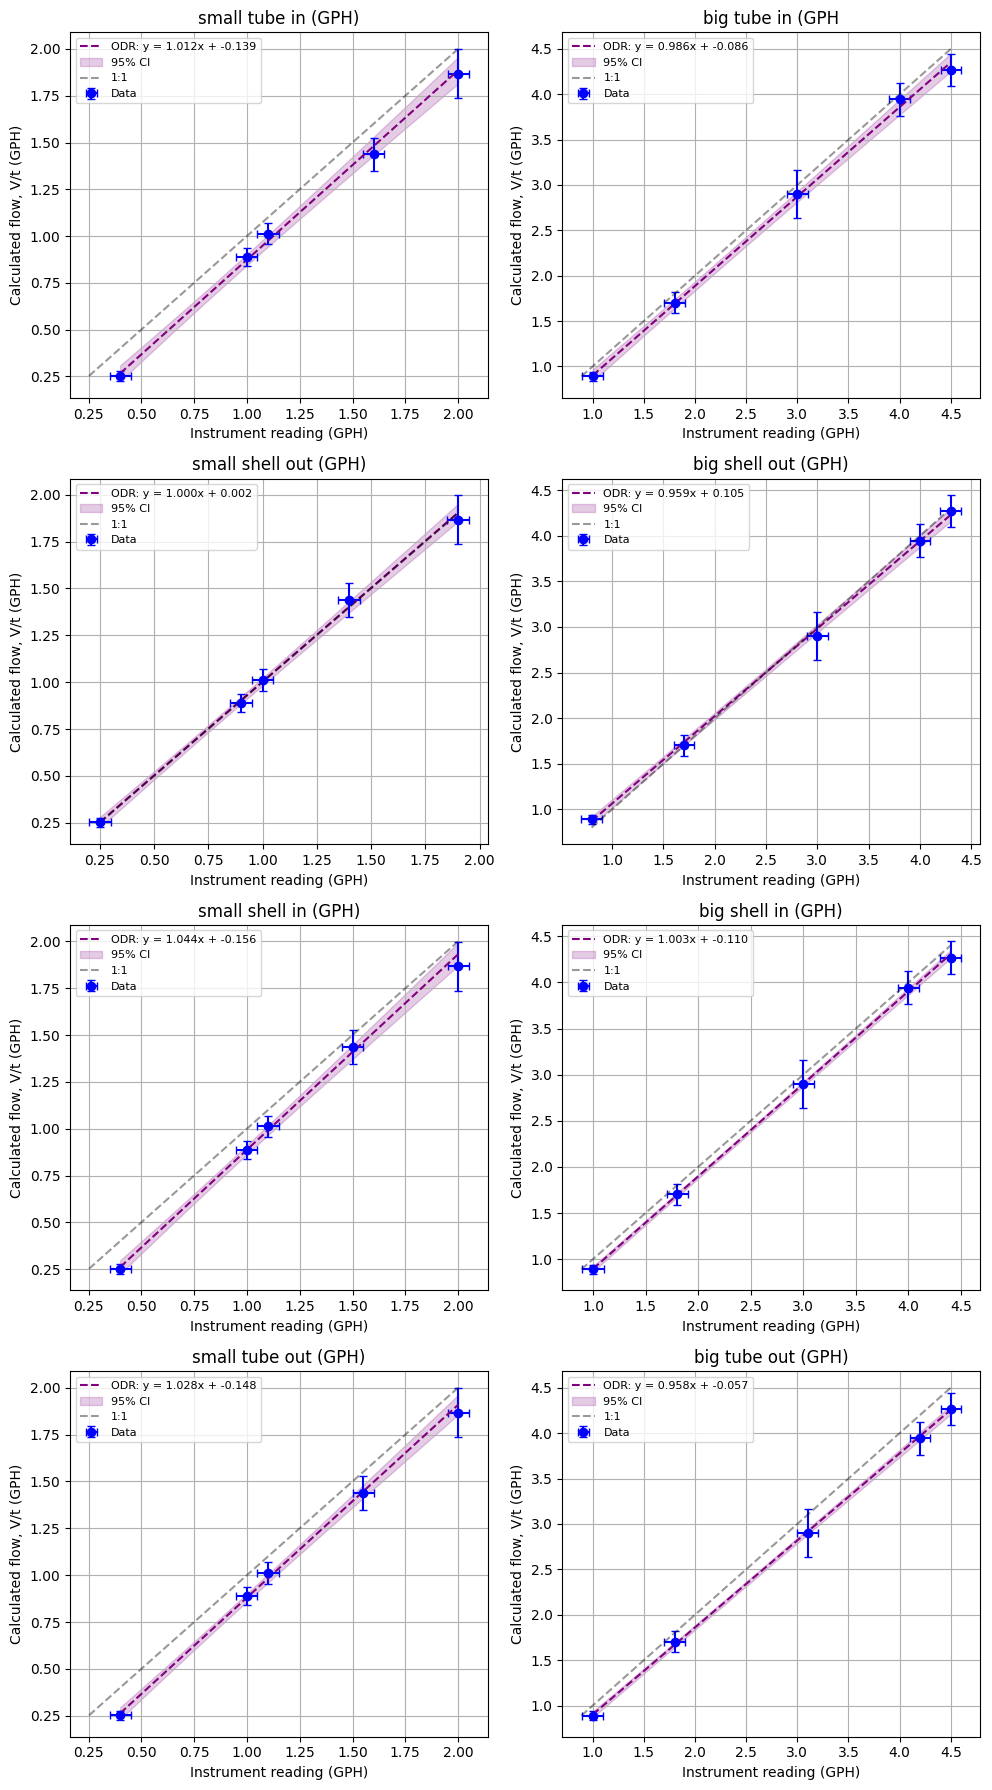

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
from uncertainties import ufloat, unumpy as unp

def get_flow_rows(table_u):
    return [r for r in table_u.index
            if "volume" not in r.lower() and "time" not in r.lower()]

def linear_model_odr(beta, x):
    return beta[0] * x + beta[1]

sets = [(small_u, Q_small_u), (big_u, Q_big_u)]

fig, axes = plt.subplots(4, 2, figsize=(10, 18))
fit_results = {}   # name -> (m_ODR, b_ODR)

for col_i, (table_u, Q_u) in enumerate(sets):
    y_values = unp.nominal_values(Q_u.values)
    y_error = unp.std_devs(Q_u.values)

    for row_i, name in enumerate(get_flow_rows(table_u)):
        ax = axes[row_i, col_i]

        x_u = table_u.loc[name].values
        x_values = unp.nominal_values(x_u)
        x_error = unp.std_devs(x_u)

        # Initial guess from a weighted least-squares fit
        slope, intercept = np.polyfit(x_values, y_values, 1, w=1 / y_error)

        # ODR fit using the x and y uncertainties
        odr_data = odr.RealData(x_values, y_values, sx=x_error, sy=y_error)
        odr_model = odr.Model(linear_model_odr)
        odr_result = odr.ODR(odr_data, odr_model, beta0=[slope, intercept]).run()

        m_ODR = ufloat(odr_result.beta[0], odr_result.sd_beta[0])
        b_ODR = ufloat(odr_result.beta[1], odr_result.sd_beta[1])
        fit_results[name] = (m_ODR, b_ODR)
        print(f"{name}: slope = {m_ODR:.4f}, intercept = {b_ODR:.4f}")

        # Covariance of the fit parameters (scaled by residual variance,
        # consistent with sd_beta)
        covariance = odr_result.cov_beta * odr_result.res_var

        # Fitted line and 95% confidence band on a smooth x grid
        xs = np.linspace(x_values.min(), x_values.max(), 100)
        y_fit = linear_model_odr(odr_result.beta, xs)
        X_matrix = np.vstack([xs, np.ones(len(xs))]).T
        y_var = np.einsum("ij,jk,ik->i", X_matrix, covariance, X_matrix)
        y_ci = 1.96 * np.sqrt(y_var)

        # Plot
        ax.errorbar(x_values, y_values, xerr=x_error, yerr=y_error,
                    fmt="o", color="b", capsize=3, label="Data")
        ax.plot(xs, y_fit, "--", color="purple",
                label=f"ODR: y = {m_ODR.n:.3f}x + {b_ODR.n:.3f}")
        ax.fill_between(xs, y_fit - y_ci, y_fit + y_ci,
                        color="purple", alpha=0.2, label="95% CI")

        lo = min(x_values.min(), y_values.min())
        hi = max(x_values.max(), y_values.max())
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="1:1")

        ax.set_title(name)
        ax.set_xlabel("Instrument reading (GPH)")
        ax.set_ylabel("Calculated flow, V/t (GPH)")
        ax.legend(fontsize=8)
        ax.grid(True)

plt.tight_layout()
plt.show()

error of calibration:

In [24]:
from uncertainties import ufloat, correlated_values, unumpy as unp

def linear_model_odr(beta, x):
    return beta[0] * x + beta[1]

def get_flow_rows(table_u):
    return [r for r in table_u.index
            if "volume" not in r.lower() and "time" not in r.lower()]

# 1. Fit each instrument and store the calibration as correlated ufloats
calibration = {}   # name -> (m, b)

for table_u, Q_u in [(small_u, Q_small_u), (big_u, Q_big_u)]:
    y = unp.nominal_values(Q_u.values)
    yerr = unp.std_devs(Q_u.values)

    for name in get_flow_rows(table_u):
        x_u = table_u.loc[name].values
        x = unp.nominal_values(x_u)
        xerr = unp.std_devs(x_u)

        slope, intercept = np.polyfit(x, y, 1, w=1 / yerr)
        res = odr.ODR(odr.RealData(x, y, sx=xerr, sy=yerr),
                      odr.Model(linear_model_odr),
                      beta0=[slope, intercept]).run()

        cov = res.cov_beta * res.res_var
        m, b = correlated_values(res.beta, cov)
        calibration[name] = (m, b)

# 2. Function that converts a reading (ufloat) to a corrected flow
def calibrate(name, reading_u):
    m, b = calibration[name]
    return m * reading_u + b

# 3. Apply the calibration to every reading in both tables
def calibrated_table(table_u):
    out = {}
    for name in get_flow_rows(table_u):
        out[name] = calibrate(name, table_u.loc[name])
    return pd.DataFrame(out).T

small_cal = calibrated_table(small_u)
big_cal = calibrated_table(big_u)

print("SMALL calibrated flow (GPH)\n", small_cal, "\n")
print("BIG calibrated flow (GPH)\n", big_cal, "\n")

# 4. Example: calibrate a new reading
new_reading = ufloat(1.3, 0.05)
print("Corrected flow:", calibrate(small_u.index[0], new_reading))

SMALL calibrated flow (GPH)
                              1 GPH      1.6 GPH      1.1 GPH        2 GPH  \
small tube in (GPH)    0.87+/-0.05  1.48+/-0.06  0.97+/-0.05  1.89+/-0.06   
small shell out (GPH)  0.90+/-0.05  1.40+/-0.05  1.00+/-0.05  1.90+/-0.06   
small shell in (GPH)   0.89+/-0.05  1.41+/-0.06  0.99+/-0.05  1.93+/-0.06   
small tube out (GPH)   0.88+/-0.05  1.45+/-0.05  0.98+/-0.05  1.91+/-0.06   

                           0.4 GPH  
small tube in (GPH)    0.27+/-0.06  
small shell out (GPH)  0.25+/-0.05  
small shell in (GPH)   0.26+/-0.06  
small tube out (GPH)   0.26+/-0.05   

BIG calibrated flow (GPH)
                          1.8 GPH        3 GPH        4 GPH      4.5 GPH  \
big tube in (GPH     1.69+/-0.10  2.87+/-0.10  3.86+/-0.11  4.35+/-0.11   
big shell out (GPH)  1.74+/-0.10  2.98+/-0.10  3.94+/-0.10  4.23+/-0.10   
big shell in (GPH)   1.70+/-0.10  2.90+/-0.10  3.90+/-0.10  4.30+/-0.10   
big tube out (GPH)   1.67+/-0.10  2.91+/-0.10  3.97+/-0.10  4.26+/-0.10

In [23]:
name = small_u.index[0]   # or any key from calibration.keys()
m, b = calibration[name]

for e in (0.0, 0.01, 0.04, 0.05, 0.2):
    y = calibrate(name, ufloat(1.3, e))
    print(f"reading error {e:<5} -> corrected error = {y.s:.6f}")

print()
print("slope m:", m.n, "+/-", m.s)
print("intercept b:", b.n, "+/-", b.s)

y0 = calibrate(name, ufloat(1.3, 0.0))   # calibration-only error
print("calibration-only error at x=1.3:", y0.s)
print("reading term at e=0.05 (|m|*e):", abs(m.n) * 0.05)

reading error 0.0   -> corrected error = 0.018745
reading error 0.01  -> corrected error = 0.021303
reading error 0.04  -> corrected error = 0.044613
reading error 0.05  -> corrected error = 0.053965
reading error 0.2   -> corrected error = 0.203285

slope m: 1.0120946703525595 +/- 0.03044390282708797
intercept b: -0.13864694634425234 +/- 0.03180799739023527
calibration-only error at x=1.3: 0.018744734495749545
reading term at e=0.05 (|m|*e): 0.05060473351762798


/usr/local/lib/python3.13/dist-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Conductivity calibration

In [15]:
C_REF = 0.1  # M
water = load_file("/content/DI_0M_10-05.xlsx").iloc[0]
kcl = load_file("/content/KCl_0.1M_10-05.xlsx").iloc[0]
V_WATER = np.array([water[f"V {st}"] for st in STREAMS])
V_REF = np.array([kcl[f"V {st}"] for st in STREAMS])

def volts_to_conc(V):
    """Per-probe linear interpolation, water -> 0.1 M. V is (n_runs, 4) in STREAMS order."""
    return C_REF * (V - V_WATER) / (V_REF - V_WATER)

pd.DataFrame({"V water": V_WATER, "V 0.1 M": V_REF}, index=STREAMS)

FileNotFoundError: [Errno 2] No such file or directory: '/content/DI_0M_10-05.xlsx'

Load runs/convert to concentration

In [ ]:
FILES = ["/content/KCl-245-5_0.1M_10-05.xlsx"]   # add more files here
df = pd.concat([load_file(f) for f in FILES], ignore_index=True)

C = volts_to_conc(df[[f"V {st}" for st in STREAMS]].values)   # mol/L
Q = df[[f"Q {st}" for st in STREAMS]].values                   # L/s
dQ = df[[f"dQ {st}" for st in STREAMS]].values
for j, st in enumerate(STREAMS):
    df[f"C {st}"] = C[:, j]

df[["file", "run"] + [f"C {st}" for st in STREAMS]].round(4)

Material balance

In [ ]:
#errors are percent error for everything
df["N in"] = Q[:, 0] * C[:, 0] + Q[:, 2] * C[:, 2]
df["N out"] = Q[:, 1] * C[:, 1] + Q[:, 3] * C[:, 3]
df["dN"] = np.sqrt(((dQ * C) ** 2).sum(axis=1))        # propagated flow error
df["closure %"] = 100 * (df["N out"] - df["N in"]) / df["N in"]
df["closes?"] = (df["N out"] - df["N in"]).abs() <= df["dN"]
df["Q tube imbalance %"] = 100 * (Q[:, 1] - Q[:, 0]) / Q[:, 0]
df["Q shell imbalance %"] = 100 * (Q[:, 3] - Q[:, 2]) / Q[:, 2]

df[["run", "N in", "N out", "dN", "closure %", "closes?",
    "Q tube imbalance %", "Q shell imbalance %"]].round(6)

Dialysis coefficient

In [ ]:
A = None  # membrane area [m^2] — fill in

df["W_R (mol/s)"] = transfer_solute(Q[:, 0], Q[:, 1], C[:, 0], C[:, 1])
df["dC_lm (M)"] = logmeanconc(C.T)
df["K_A*A (m^3/s)"] = df["W_R (mol/s)"] / (df["dC_lm (M)"] * 1000)
if A:
    df["K_A (m/s)"] = k_a_calc(df["W_R (mol/s)"], A, df["dC_lm (M)"])

df[["run", "W_R (mol/s)", "dC_lm (M)", "K_A*A (m^3/s)"] + (["K_A (m/s)"] if A else [])]

Dialyzer Geometry

In [ ]:
DIALYZERS = {
    "Optiflux F16NR": dict(L=0.260, A=1.5, shell_od=42.9e-3, shell_t=3e-3),
    "Rexeed 21S":     dict(L=0.290, A=2.1, shell_od=46.9e-3, shell_t=3e-3),
}
DIALYZER = "Optiflux F16NR"   # <-- set to the module you used

g = DIALYZERS[DIALYZER]
L, A = g["L"], g["A"]                 # fiber length [m], internal membrane area [m^2]
D_I = 0.200e-3                         # fiber ID [m]
Z = 0.045e-3                           # membrane thickness [m]
r_i = D_I / 2
r_o = r_i + Z
D_O = 2 * r_o

N_FIB = A / (np.pi * D_I * L)          # number of fibers
D_SHELL = g["shell_od"] - 2 * g["shell_t"]   # shell ID [m]

pd.Series({"fibers": N_FIB, "shell ID (m)": D_SHELL, "r_i (m)": r_i, "r_o (m)": r_o})

Shell-side hydraulic diameter

In [ ]:
A_C = np.pi / 4 * (D_SHELL**2 - N_FIB * D_O**2)   # shell flow area [m^2]
P_WET = N_FIB * np.pi * D_O                        # wetted perimeter of all fibers [m]
D_H = 4 * A_C / P_WET

pd.Series({"A_c (m^2)": A_C, "P (m)": P_WET, "D_H (m)": D_H})

K_a from 2 a and b

In [ ]:
df["K_A (m/s)"] = k_a_calc(df["W_R (mol/s)"], A, df["dC_lm (M)"])
df[["run", "K_A (m/s)"]]

Equation 5: velocities and reynolds numbers

In [ ]:
Q_TUBE = (df["Q Tube In"] + df["Q Tube Out"]) / 2 / 1000     # L/s -> m^3/s
Q_SHELL = (df["Q Shell In"] + df["Q Shell Out"]) / 2 / 1000

df["u tube (m/s)"] = Q_TUBE / (N_FIB * np.pi * r_i**2)
df["u shell (m/s)"] = Q_SHELL / A_C
df["Re tube"] = D_I * df["u tube (m/s)"] / NU
df["Re shell"] = D_H * df["u shell (m/s)"] / NU

df[["run", "u tube (m/s)", "u shell (m/s)", "Re tube", "Re shell"]]

Sherwood numbers

In [ ]:
df["Sh tube"] = 3.66 + df["Re tube"]**2.24 * (SC * D_I / L)**(1/3)
df["Sh shell"] = 1.39 * df["Re shell"]**2.11 * (SC * D_H / L)**(1/3)

df[["run", "Sh tube", "Sh shell"]]

2c: BL coefficients

In [ ]:
df["k_RA (m/s)"] = df["Sh tube"] * D_AB / D_I
df["k_DA (m/s)"] = df["Sh shell"] * D_AB / D_H

df[["run", "k_RA (m/s)", "k_DA (m/s)"]]

2d: membrane coefficient

In [ ]:
resid = 1 / df["K_A (m/s)"] - 1 / df["k_RA (m/s)"] - r_i / (r_o * df["k_DA (m/s)"])
df["k_mA (m/s)"] = r_i * np.log(r_o / r_i) / ((r_o - r_i) * resid)

df[["run", "K_A (m/s)", "k_RA (m/s)", "k_DA (m/s)", "k_mA (m/s)"]]

3: epsilon/tau

In [ ]:
df["eps/tau"] = df["k_mA (m/s)"] * Z / D_AB


ok = df["eps/tau"] > 0
print(f"mean eps/tau (valid runs) = {df.loc[ok, 'eps/tau'].mean():.3f} "
      f"± {df.loc[ok, 'eps/tau'].std():.3f}")

df[["run","eps/tau"]]